In [26]:
#Importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

%matplotlib inline

In [27]:
#Read csv file

df = pd.read_csv('National_River_Toxin_Dataset_1.csv')

In [28]:
#Checking data
df.head()

,Date,River_System,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
0,2018-01-01,Amazon,7.030015,19.136212,2.500401,0.465454,3.578886,11.627614,0.522167,7.830196
1,2018-01-01,Nile,7.421766,21.406824,3.469443,0.859716,5.352155,10.538171,0.510465,8.130328
2,2018-01-01,Yangtze,7.133612,18.419902,3.806935,0.824085,5.277814,7.865033,0.585096,8.120874
3,2018-01-01,Mississippi,7.863001,18.014871,3.438131,0.500597,3.473881,11.143068,0.438248,6.853816
4,2018-01-01,Danube,7.527686,16.622289,2.188210,0.424178,2.454209,8.043467,0.422244,8.197925


In [29]:
#data information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1305 non-null   object 
 1   River_System      1305 non-null   object 
 2   pH_Level          1278 non-null   float64
 3   Temperature       1278 non-null   float64
 4   Lead              1285 non-null   float64
 5   Mercury           1278 non-null   float64
 6   Arsenic           1279 non-null   float64
 7   Nitrates          1265 non-null   float64
 8   Phosphates        1282 non-null   float64
 9   Dissolved_Oxygen  1284 non-null   float64
dtypes: float64(8), object(2)
memory usage: 102.1+ KB


In [30]:
#shape of data
df.shape


(1305, 10)

In [31]:
#Descriptive staistics using describe
df.describe()

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
count,1278.000000,1278.000000,1285.000000,1278.000000,1279.000000,1265.000000,1282.000000,1284.000000
mean,7.353247,20.041668,3.011035,0.596108,3.597916,10.038789,0.497162,8.023795
std,0.349114,4.063638,0.874431,0.175150,0.992052,2.096641,0.106304,1.064190
min,6.465087,9.891618,0.551349,0.157117,1.485608,2.025075,0.144044,5.041394
25%,7.101324,16.813976,2.366298,0.462683,2.836160,8.701188,0.422006,7.269386
50%,7.339326,20.039121,3.000714,0.599186,3.511678,10.089112,0.497631,8.007448
75%,7.585733,23.358634,3.676560,0.734863,4.298946,11.391686,0.572888,8.740828
max,8.392902,30.749449,5.800963,1.057494,6.232902,16.547073,0.870007,11.228677


In [7]:
#Check missing values
df.isnull().sum()

Date                 0
River_System         0
pH_Level            27
Temperature         27
Lead                20
Mercury             27
Arsenic             26
Nitrates            40
Phosphates          23
Dissolved_Oxygen    21
dtype: int64

In [34]:
#Fill missing values in numeric columns only
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

In [35]:
#Check missing values
df.isnull().sum()

Date                0
River_System        0
pH_Level            0
Temperature         0
Lead                0
Mercury             0
Arsenic             0
Nitrates            0
Phosphates          0
Dissolved_Oxygen    0
dtype: int64

In [36]:
#Convert data type e.g date to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

In [37]:
df

,Date,River_System,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
0,2018-01-01,Amazon,7.030015,19.136212,2.500401,0.465454,3.578886,11.627614,0.522167,7.830196
1,2018-01-01,Nile,7.421766,21.406824,3.469443,0.859716,5.352155,10.538171,0.510465,8.130328
2,2018-01-01,Yangtze,7.133612,18.419902,3.806935,0.824085,5.277814,7.865033,0.585096,8.120874
3,2018-01-01,Mississippi,7.863001,18.014871,3.438131,0.500597,3.473881,11.143068,0.438248,6.853816
4,2018-01-01,Danube,7.527686,16.622289,2.188210,0.424178,2.454209,8.043467,0.422244,8.197925
...,...,...,...,...,...,...,...,...,...,...
1300,2022-12-26,Amazon,7.353247,21.760533,1.656464,0.466371,2.778257,8.932392,0.521475,8.789334
1301,2022-12-26,Nile,7.214448,21.005255,1.395876,0.743100,4.243743,7.766917,0.624352,7.907600
1302,2022-12-26,Yangtze,6.852077,18.841392,3.677048,0.634460,5.958020,9.855321,0.567842,10.983113
1303,2022-12-26,Mississippi,7.923046,18.886274,3.229030,0.526015,3.904349,10.859932,0.498410,8.284721


In [39]:
#Average toxin level for each river
average_toxin_level = df[['Lead','Mercury','Arsenic']].mean()
print(f"Average Toxin Level:\n {average_toxin_level}")

Average Toxin Level:
 Lead       3.011035
Mercury    0.596108
Arsenic    3.597916
dtype: float64


In [45]:
#Top 5 most polluted rivers by average Lead levels
#top_polluted_rivers = df.groupby('River_System')['Lead'].mean().sort_values(ascending=False).head(5)
#print(f"Top polluted rivers by Lead Level:\n {top_polluted_rivers}")

In [46]:
#Top 5 most polluted rivers by average Lead levels
top_polluted_rivers = df.groupby('River_System')['Lead'].mean().sort_values(ascending=False)
print(f"Top polluted rivers by Lead Level:\n {top_polluted_rivers}.head(5)")

Top polluted rivers by Lead Level:
 River_System
Yangtze        4.011200
Mississippi    3.478198
Nile           2.990203
Danube         2.544912
Amazon         2.030662
Name: Lead, dtype: float64.head(5)


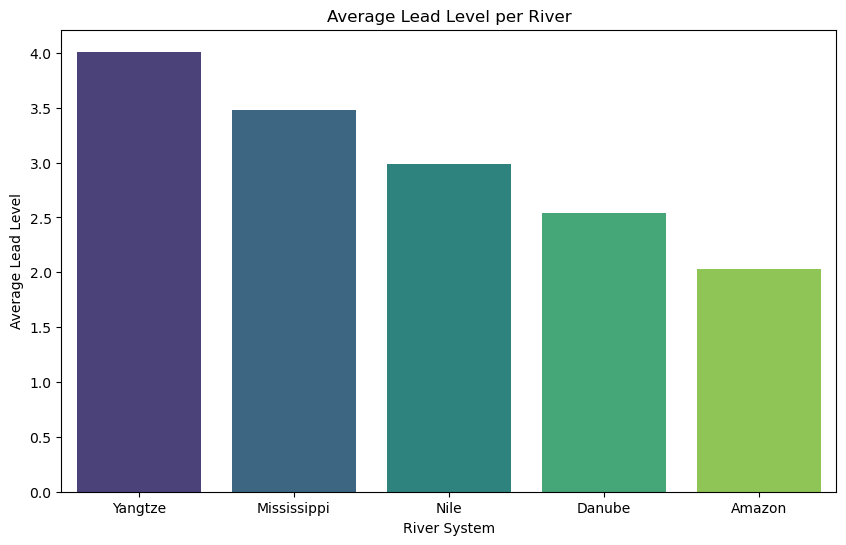

In [50]:
# Bar Chart for average lead level per river
#plt.figure(figsize=(10,6))
#top_polluted_rivers.plot(kind = 'bar', color='skyblue')
#plt.title('Average Lead Level per River')
#plt.xlabel('River System')
#plt.ylabel('Average Lead Level')
#plt.show()

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_polluted_rivers.index,
    y=top_polluted_rivers.values,
    hue=top_polluted_rivers.index,
    palette='viridis',
    legend=False
)

plt.title('Average Lead Level per River')
plt.xlabel('River System')
plt.ylabel('Average Lead Level')

plt.show()

<Figure size 1000x600 with 0 Axes>

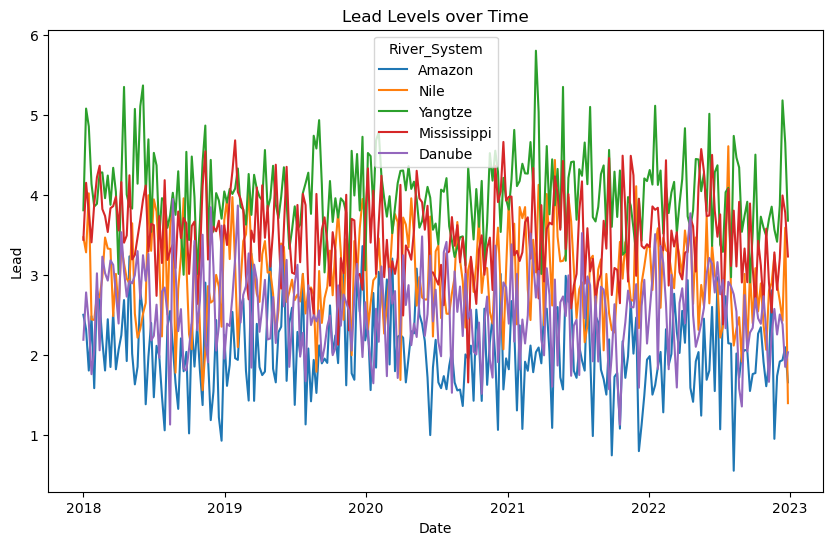

In [52]:
#line graph for toxin levels over time
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Lead', data=df, hue='River_System', errorbar=None)
errorbar=None
plt.title('Lead Levels over Time')
plt.xlabel('Date')
plt.ylabel('Lead')
plt.show()

In [55]:
#Compute Correlation matrix using only numeric columns
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
pH_Level,1.000000,0.167589,0.319700,0.137656,0.042514,0.082121,0.089348,-0.058682
Temperature,0.167589,1.000000,0.124512,0.160928,0.044863,0.246166,0.314542,-0.279058
Lead,0.319700,0.124512,1.000000,0.538168,0.566595,0.029522,-0.000937,-0.027448
Mercury,0.137656,0.160928,0.538168,1.000000,0.685925,0.062318,0.005734,-0.001926
Arsenic,0.042514,0.044863,0.566595,0.685925,1.000000,0.034924,-0.004483,0.020435
Nitrates,0.082121,0.246166,0.029522,0.062318,0.034924,1.000000,0.099595,-0.092371
Phosphates,0.089348,0.314542,-0.000937,0.005734,-0.004483,0.099595,1.000000,-0.125113
Dissolved_Oxygen,-0.058682,-0.279058,-0.027448,-0.001926,0.020435,-0.092371,-0.125113,1.000000


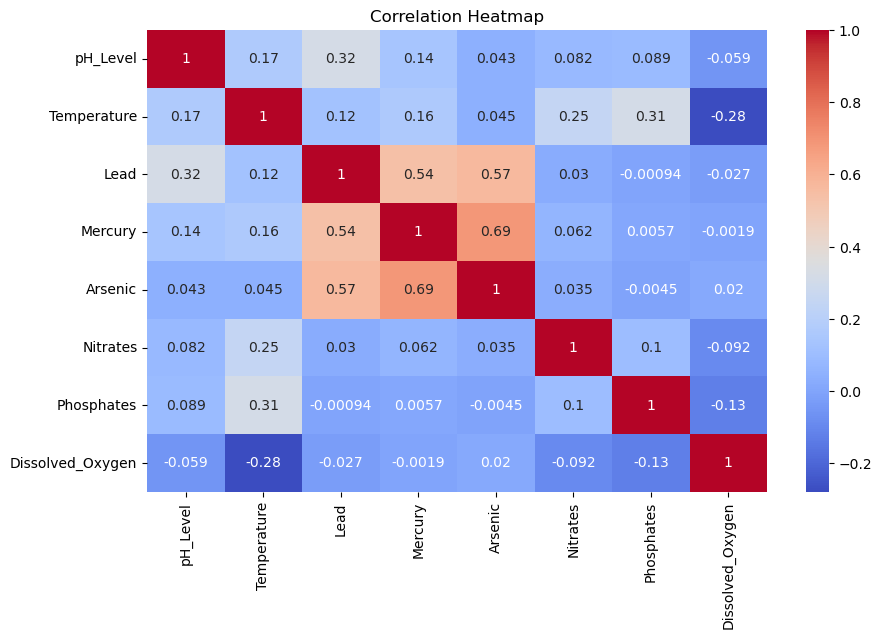

In [56]:
#Heatmap for correlation between different parameters
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [58]:
#T-test between two rivers (e.gAmazon and Nile)
amazon_data = df[df['River_System'] == 'Amazon']['Lead']
nile_data = df[df['River_System']== 'Nile']['Lead']
t_stat, p_value = stats.ttest_ind(amazon_data,nile_data)
print(f"T-Test between Amazon and Nile: T-Statistic = {t_stat}, P_value = {p_value}")

T-Test between Amazon and Nile: T-Statistic = -20.23821779031797, P_value = 1.3375120881428663e-67


In [63]:
#Linear Regression  Analysis for toxin levels and pH
# Reshape X to be 2D
X = df[['pH_Level']]   # double brackets make it a DataFrame (2D)
y = df['Lead']

# Create and fit model
model = LinearRegression()
model.fit(X, y)

# Print coefficients
print(f"Linear Regression Coefficient: {model.coef_}")
print(f"Linear Regression Intercept: {model.intercept_}")

Linear Regression Coefficient: [0.80294889]
Linear Regression Intercept: -2.89324669492776
